# EEG Observation Mapping Audit

## Can neurolib thalamocortical states support a real Fpz-Cz EEG observation?

This notebook audits the missing **measurement operator** between the neurolib
thalamocortical model and the real Sleep-EDF `EEG Fpz-Cz` bipolar derivation.
It does not train SNPE, does not create a simulation bank, and does not call a
model state “simulated EEG” merely because its waveform or PSD looks similar.

The audit separates five claims:

1. **Code-level availability:** a variable can be recorded.
2. **Schema-level compatibility:** an algorithm returns a fixed numeric field.
3. **Unit/semantic parity:** the field has the same physical meaning.
4. **Distributional similarity:** normalized shapes happen to resemble one another.
5. **Physiological validity:** a validated source-to-sensor model supports the comparison.

Only (1) and selected parts of (2)/(4) are currently testable. A similar
z-scored waveform or unit-area PSD is screening evidence, not a forward-model
validation.

## 1. Environment, protected files, and audit scope

All computation must run in the existing `neurolib` conda environment. The
kernel ID is `python3`, whose kernelspec executable points into that environment.
The hashes below protect notebooks 01-07. Paths in scientific artifacts are
project-relative; no raw EEG array or simulation time series is exported.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as im
import json
import os
from pathlib import Path
import platform
import subprocess
import sys
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import scipy
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "S4_sbi").exists():
    ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "S4_sbi").exists(), ROOT
SRC = ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from sleep_sbi.eeg_observation_mapping_audit import (
    audit_parameter_sets,
    extractor_screening,
    load_real_reference,
    mapping_option_decisions,
    range_statistics,
    run_state_audit,
    shape_metrics,
    state_catalog,
)

OUT = ROOT / "S4_sbi" / "results" / "eeg_observation_mapping_audit"
FIG = OUT / "figures"
HTML = ROOT / "S4_sbi" / "results" / "overnight_observation_ablation" / "html"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
HTML.mkdir(parents=True, exist_ok=True)

PROTECTED = [
    "S4_sbi/notebooks/01_observation.ipynb",
    "S4_sbi/notebooks/01_observation_annotated.ipynb",
    "S4_sbi/notebooks/01_Pyloric_Inspired_Observation.ipynb",
    "S4_sbi/notebooks/01_Pyloric_Inspired_Observation_annotated.ipynb",
    "S4_sbi/notebooks/02_Observation_Schema_Comparison.ipynb",
    "S4_sbi/notebooks/03_Observation_Schema_Freeze.ipynb",
    "S4_sbi/notebooks/04_Real_Simulation_Extractor_Parity.ipynb",
    "S4_sbi/notebooks/05_Pilot_SNPE_Ablation.ipynb",
    "S4_sbi/notebooks/06_Ablation_Diagnostics.ipynb",
    "S4_sbi/notebooks/07_Simulator_Observable_Adapter_Validation.ipynb",
]

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

protected_hashes_start = {
    rel: sha256(ROOT / rel) for rel in PROTECTED if (ROOT / rel).exists()
}
git_status_start = subprocess.run(
    ["git", "status", "--short"], cwd=ROOT, text=True, capture_output=True, check=True
).stdout.splitlines()
git_diff_stat_start = subprocess.run(
    ["git", "diff", "--stat"], cwd=ROOT, text=True, capture_output=True, check=True
).stdout.splitlines()

packages = {}
for name in ["neurolib", "numpy", "scipy", "pandas", "matplotlib", "mne", "torch", "sbi", "fooof", "nbformat", "nbclient"]:
    try:
        packages[name] = im.version(name)
    except im.PackageNotFoundError:
        packages[name] = "not installed"

environment_report = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "working_directory": str(ROOT),
    "conda_default_env": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys_executable": sys.executable,
    "sys_prefix": sys.prefix,
    "python_version": platform.python_version(),
    "kernel_id": "python3",
    "kernel_display_name": "Python 3 (ipykernel)",
    "packages": packages,
    "protected_notebook_sha256_start": protected_hashes_start,
    "git_status_short_start": git_status_start,
    "git_diff_stat_start": git_diff_stat_start,
}
assert environment_report["conda_default_env"] == "neurolib"
assert "neurolib" in sys.executable.lower()
display(pd.Series({k: v for k, v in environment_report.items() if k not in {"packages", "protected_notebook_sha256_start", "git_status_short_start", "git_diff_stat_start"}}).to_frame("value"))
display(pd.Series(packages, name="version").to_frame())
print("git status --short (start):")
print("\n".join(git_status_start))
print("\ngit diff --stat (start):")
print("\n".join(git_diff_stat_start))

,value
created_utc,2026-07-27T14:23:22.726739+00:00
working_directory,D:\Year3_Mao_Projects\sleep_loop
conda_default_env,neurolib
sys_executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
sys_prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
python_version,3.10.20
kernel_id,python3
kernel_display_name,Python 3 (ipykernel)


,version
neurolib,0.6.1
numpy,2.2.6
scipy,1.15.2
pandas,2.3.3
matplotlib,3.10.8
mne,1.9.0
torch,2.5.1
sbi,0.26.1
fooof,1.1.1
nbformat,5.10.4


git status --short (start):
 D S4_sbi/compute_xobs_from_eeg.py
 D S4_sbi/compute_xobs_from_eeg_v1_buggy.py
 D S4_sbi/compute_xobs_from_eeg_v2.py
 M S4_sbi/compute_xobs_from_eeg_v4.py
 M S4_sbi/notebooks/01_Pyloric_Inspired_Observation_annotated.ipynb
 D S4_sbi/plot_scan_diagnostics.py
 D S4_sbi/run_sbc_standalone.py
 D S4_sbi/scan_xobs_params.py
 D S4_sbi/x_obs.npz
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.docx
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.md
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.tex
 M docs/Claude_Writing/build_manuscript_docx.py
 M docs/implementation_plan_v8_progress_1.md
 M models/s4_personalize_fig7_v2.py
 M valid_scripts/validate_so_waveform_heldout.py
 M valid_scripts/validate_spindle_density_heldout.py
?? S4_sbi/legacy/
?? S4_sbi/notebooks/02_Observation_Schema_Comparison.ipynb
?? S4_sbi/notebooks/03_Observation_Schema_Freeze.ipynb
?? S4_sbi/notebooks/04_Real_Simulation_Extractor_Parity.ipynb
?? S4_sbi/notebooks/05_Pilot_SNPE_Ablation.ipynb

## 2. Code-level evidence: what Figure 5/7 actually compared

The fitting target and model signal share a Welch-style spectral comparison,
but they do **not** share a measurement model:

- Real side: `EEG Fpz-Cz`, converted from MNE volts to $\mu V$, 30-second N3
  epochs, per-epoch QC, then arithmetic-mean PSD.
- Model side: cortical node 0 of `r_mean_EXC`, converted from kHz to Hz, with
  5 seconds removed from a 60-second run, then a rate PSD.

Consequently, the optimization supports **spectral shape matching between
modalities**, not equality between simulated and measured scalp voltage. The
table also flags one legacy comment that calls firing rate a membrane potential;
the executable code and neurolib state definition contradict that wording.

The installed neurolib source also contains a generic MNE/BEM `LeadfieldGenerator`. It is not used by `sleep_loop`, is not connected to the two-node model, and does not define which model state is an oriented cortical dipole source. It is therefore a possible Route-2 geometry component, not an existing measurement model.

In [2]:
code_evidence = pd.DataFrame([
    {
        "source": "models/s4_personalize_fig7_v7.py:226-227",
        "evidence": "default/output vars are r_mean_EXC and r_mean_INH; comment names cortical EXC firing rate",
        "implication": "fitting signal is a population firing rate",
        "status": "code evidence",
    },
    {
        "source": "models/s3_sleep_kernel.py:13; models/s3_band_power_bars.py:2-13,248-266",
        "evidence": "Figure-5-era workflow converts r_mean_EXC kHz to Hz and computes cortical/thalamic firing-rate Welch PSD; an output is named EEGlike",
        "implication": "EEG-aligned frequency bands and a filename do not implement a source-to-sensor measurement",
        "status": "shape-level comparison / naming caveat",
    },
    {
        "source": "models/s4_personalize_fig7_v7.py:913-924",
        "evidence": "node 0 r_mean_EXC is multiplied by 1000 (kHz to Hz); first 5 s removed",
        "implication": "model unit is Hz and post-warm-up duration is 55 s",
        "status": "code evidence",
    },
    {
        "source": "models/s4_personalize_fig7_v7.py:930-972",
        "evidence": "cortical firing-rate PSD is compared with target PSD in log space",
        "implication": "shared spectral loss is not a shared measurement operator",
        "status": "code evidence",
    },
    {
        "source": "models/s4_personalize_fig7_v7.py:797-840",
        "evidence": "Fpz-Cz is converted V to uV, QC-filtered per N3 epoch, and epoch PSDs are averaged",
        "implication": "real target is a bipolar scalp-voltage PSD in uV^2/Hz",
        "status": "code evidence",
    },
    {
        "source": "models/s4_personalize_fig7_v8.py:617-662",
        "evidence": "T13 applies cortical spindle observability logic to r_ctx",
        "implication": "T13 is an internal rate-based audit, not a scalp detector",
        "status": "code evidence",
    },
    {
        "source": "neurolib/.../builder/aln.py:414-421,535-559",
        "evidence": "ALN r_mean is a firing-rate state; voltage is a lookup used inside the dynamics, not a recorded state",
        "implication": "no cortical membrane-potential output is present in the project network",
        "status": "library code evidence",
    },
    {
        "source": "neurolib/.../builder/thalamus.py:125-135,304-311",
        "evidence": "TCR/TRN include V and r_mean states; V is an internal thalamic membrane voltage",
        "implication": "thalamic V cannot be substituted for Fpz-Cz",
        "status": "library code evidence",
    },
    {
        "source": "valid_scripts/validate_so_waveform_heldout.py:196",
        "evidence": "legacy prose calls r_mean_EXC a membrane potential represented by activation rate",
        "implication": "the variable is still firing rate according to executable/library definitions",
        "status": "Reviewer note / Documentation-code mismatch",
    },
    {
        "source": "valid_scripts/validate_so_waveform_heldout.py:209-276",
        "evidence": "real EEG and r_ctx waveform snippets are individually z-scored before template comparison",
        "implication": "the result tests normalized morphology only, not raw amplitude parity",
        "status": "shape-level validation",
    },
    {
        "source": "S4_sbi/src/sleep_sbi/observation.py:372-424,511-711",
        "evidence": "PSD metadata is uV^2/Hz and SO detector uses a 75 uV half-wave threshold",
        "implication": "EEG extractor cannot be reused unchanged for native model states",
        "status": "measurement blocker",
    },
    {
        "source": "neurolib/utils/leadfield.py:15-60,237-260,488-569",
        "evidence": "neurolib provides a generic MNE/BEM lead-field generator and region downsampling utility",
        "implication": "potential Route-2 geometry tool, but no model-state dipole source or Fpz-Cz mapping is defined",
        "status": "library utility; not an integrated measurement model",
    },
    {
        "source": "project-wide *.py search",
        "evidence": "sleep_loop has no lead-field call, cortical LFP, source-to-sensor forward model, or validated Fpz-Cz measurement function",
        "implication": "there is no existing project measurement model",
        "status": "negative project search result",
    },
])
display(code_evidence)

,source,evidence,implication,status
0,models/s4_personalize_fig7_v7.py:226-227,default/output vars are r_mean_EXC and r_mean_...,fitting signal is a population firing rate,code evidence
1,models/s3_sleep_kernel.py:13; models/s3_band_p...,Figure-5-era workflow converts r_mean_EXC kHz ...,EEG-aligned frequency bands and a filename do ...,shape-level comparison / naming caveat
2,models/s4_personalize_fig7_v7.py:913-924,node 0 r_mean_EXC is multiplied by 1000 (kHz t...,model unit is Hz and post-warm-up duration is ...,code evidence
3,models/s4_personalize_fig7_v7.py:930-972,cortical firing-rate PSD is compared with targ...,shared spectral loss is not a shared measureme...,code evidence
4,models/s4_personalize_fig7_v7.py:797-840,"Fpz-Cz is converted V to uV, QC-filtered per N...",real target is a bipolar scalp-voltage PSD in ...,code evidence
5,models/s4_personalize_fig7_v8.py:617-662,T13 applies cortical spindle observability log...,"T13 is an internal rate-based audit, not a sca...",code evidence
6,"neurolib/.../builder/aln.py:414-421,535-559",ALN r_mean is a firing-rate state; voltage is ...,no cortical membrane-potential output is prese...,library code evidence
7,"neurolib/.../builder/thalamus.py:125-135,304-311",TCR/TRN include V and r_mean states; V is an i...,thalamic V cannot be substituted for Fpz-Cz,library code evidence
8,valid_scripts/validate_so_waveform_heldout.py:196,legacy prose calls r_mean_EXC a membrane poten...,the variable is still firing rate according to...,Reviewer note / Documentation-code mismatch
9,valid_scripts/validate_so_waveform_heldout.py:...,real EEG and r_ctx waveform snippets are indiv...,"the result tests normalized morphology only, n...",shape-level validation


## 3. Available simulator outputs and internal state variables

The project network formally records `r_mean_EXC` and `r_mean_INH`. For this
audit only, neurolib's output list is expanded so already integrated states can
be inspected. This does not change differential equations, parameters, noise,
or time stepping.

The additional candidates include ALN input/current states and adaptation
current, plus TCR/TRN membrane voltages. None is automatically an EEG or LFP:
EEG depends on transmembrane source geometry, cortical orientation, volume
conduction, sensor montage, reference, and measurement noise. Equal-weight
EXC/INH sums and differences are explicitly uncalibrated screening contrasts.

In [3]:
parameter_sets = audit_parameter_sets()
parameter_table = pd.DataFrame([
    {
        "identifier": p.identifier,
        "model_version": p.model_version,
        "source": p.source,
        **p.parameters,
    }
    for p in parameter_sets
])
assert list(parameter_table["identifier"]) == ["v7_fitted", "v8_fitted", "v8a_local_best"]
display(parameter_table)

print("Running three small, existing 60-second parameter sets...")
audits = []
for parameter_set in parameter_sets:
    result = run_state_audit(parameter_set)
    audits.append(result)
    print(
        f"{parameter_set.identifier}: runtime={result.runtime_s:.2f}s, "
        f"fs={result.fs_hz:.1f} Hz, post-warm-up={len(next(iter(result.signals.values()))) / result.fs_hz:.1f}s"
    )

run_summary = pd.DataFrame([
    {
        "parameter_set": audit.parameter_set.identifier,
        "model_version": audit.parameter_set.model_version,
        "source": audit.parameter_set.source,
        "runtime_s": audit.runtime_s,
        "simulation_duration_s": audit.duration_s,
        "warm_up_removed_s": audit.warm_up_s,
        "post_warm_up_duration_s": len(next(iter(audit.signals.values()))) / audit.fs_hz,
        "fs_hz": audit.fs_hz,
        "screening_epoch_s": 30.0,
        "recorded_or_derived_signal_count": len(audit.signals),
        "failed": False,
    }
    for audit in audits
])
display(run_summary)

catalog = state_catalog(audits[0])
assert not catalog["is_validated_scalp_eeg_proxy"].any()
display(catalog)

,identifier,model_version,source,mue,mui,b,tauA,g_LK,g_h,c_th2ctx,c_ctx2th
0,v7_fitted,v7,data/patient_params_fig7_v7_SC4001.json,3.801329,2.724747,42.548128,1042.897340,0.052266,0.066072,0.012676,0.056227
1,v8_fitted,v8,data/patient_params_fig7_v8_SC4001.json,4.151310,2.719276,32.472799,1418.554270,0.051219,0.053043,0.029332,0.131831
2,v8a_local_best,v8a_t13,outputs/v8a_ultra_narrow_t6_t13_search/best_so...,3.521318,2.885064,35.851259,1220.029899,0.050246,0.054287,0.067380,0.125349


Running three small, existing 60-second parameter sets...


D:\Year3_Mao_Projects\sleep_loop\models\s4_personalize_fig7_v7.py:138: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


v7_fitted: runtime=8.71s, fs=1000.0 Hz, post-warm-up=55.0s


v8_fitted: runtime=4.70s, fs=1000.0 Hz, post-warm-up=55.0s


v8a_local_best: runtime=4.79s, fs=1000.0 Hz, post-warm-up=55.0s


,parameter_set,model_version,source,runtime_s,simulation_duration_s,warm_up_removed_s,post_warm_up_duration_s,fs_hz,screening_epoch_s,recorded_or_derived_signal_count,failed
0,v7_fitted,v7,data/patient_params_fig7_v7_SC4001.json,8.712872,60.0,5.0,55.0,1000.0,30.0,19,False
1,v8_fitted,v8,data/patient_params_fig7_v8_SC4001.json,4.702540,60.0,5.0,55.0,1000.0,30.0,19,False
2,v8a_local_best,v8a_t13,outputs/v8a_ultra_narrow_t6_t13_search/best_so...,4.790003,60.0,5.0,55.0,1000.0,30.0,19,False


,signal,unit,meaning,location,availability,fs_hz,post_warm_up_duration_s,is_validated_scalp_eeg_proxy
0,cortex_r_exc,Hz,cortical excitatory population firing rate,cortex,project-recorded,1000.0,55.0,False
1,cortex_r_inh,Hz,cortical inhibitory population firing rate,cortex,project-recorded,1000.0,55.0,False
2,cortex_rate_e_minus_i,Hz,equal-weight EXC minus INH firing-rate contrast,cortex,audit-derived; weights not physiologically cal...,1000.0,55.0,False
3,cortex_rate_e_plus_i,Hz,equal-weight EXC plus INH firing-rate sum,cortex,audit-derived; weights not physiologically cal...,1000.0,55.0,False
4,cortex_I_mu_exc,mV/ms,ALN excitatory-mass mean input/current drive s...,cortex,neurolib state; not recorded by project network,1000.0,55.0,False
5,cortex_I_mu_inh,mV/ms,ALN inhibitory-mass mean input/current drive s...,cortex,neurolib state; not recorded by project network,1000.0,55.0,False
6,cortex_adaptation_I_A,pA,ALN excitatory adaptation current,cortex,neurolib ALNNode output; not project-recorded,1000.0,55.0,False
7,cortex_effective_drive,mV/ms,"I_mu_EXC - I_A_EXC/C, the ALN transfer-functio...",cortex,audit-derived from model states,1000.0,55.0,False
8,cortex_syn_mu_exc_on_exc,dimensionless synaptic state,mean excitatory synaptic state driving ALN EXC...,cortex,neurolib state; not project-recorded,1000.0,55.0,False
9,cortex_syn_mu_inh_on_exc,dimensionless synaptic state,mean inhibitory synaptic state driving ALN EXC...,cortex,neurolib state; not project-recorded,1000.0,55.0,False


## 4. Real EEG reference and accounting

The real reference is rebuilt through the unchanged Observation pipeline:
SC4001, `EEG Fpz-Cz`, 100 Hz, native 30-second boundaries, Stage 3 and Stage 4
mapped to N3, and the existing 200 $\mu V$ peak-to-peak QC. The 142 retained
epochs remain separate for PSD and autocorrelation aggregation.

The representative trace is selected reproducibly as the retained epoch with
median peak-to-peak amplitude. It is plotted but never serialized as an array.

In [4]:
real = load_real_reference()
assert len(real.retained_epoch_indices) + len(real.rejected_epoch_indices) == len(real.n3_epoch_indices)
assert len(real.n3_epoch_indices) == 220
assert len(real.retained_epoch_indices) == 142
assert len(real.rejected_epoch_indices) == 78
assert real.segments_uv.shape == (142, 3000)
display(pd.Series(real.metadata, name="value").to_frame())
print("Representative retained PSG epoch:", real.representative_epoch_index)

,value
subject_id,SC4001
channel,EEG Fpz-Cz
unit,uV
reference,bipolar derivation Fpz-Cz as recorded; no addi...
recording_duration_s,79500.0
total_epoch_count,2650
n3_epoch_count,220
retained_epoch_count,142
rejected_epoch_count,78
epoch_duration_s,30.0


Representative retained PSG epoch: 1050


## 5. Raw-unit ranges: no cross-modal amplitude claim

This table preserves each native unit. A value in Hz, mV/ms, pA, dimensionless
synaptic state, or thalamic mV is not compared numerically with scalp $\mu V$.
Linear scaling could make the ranges overlap, but cannot supply the missing
channel/reference physics. In particular, fitting a scale to SC4001 would risk
leaking the observation into feature design.

,parameter_set,model_version,signal,unit,meaning,n_samples,duration_s,minimum,maximum,mean,std,median,iqr,peak_to_peak,finite
0,v7_fitted,v7,cortex_r_exc,Hz,cortical excitatory population firing rate,30000,30.0,2.388052e-08,61.369179,6.469373,13.462695,0.007270,1.173739,61.369179,True
1,v7_fitted,v7,cortex_r_inh,Hz,cortical inhibitory population firing rate,30000,30.0,2.500952e+01,108.674491,48.224694,25.833496,34.810681,15.278048,83.664969,True
2,v7_fitted,v7,cortex_rate_e_minus_i,Hz,equal-weight EXC minus INH firing-rate contrast,30000,30.0,-8.481629e+01,-25.009443,-41.755320,14.708952,-34.780727,12.990681,59.806849,True
3,v7_fitted,v7,cortex_rate_e_plus_i,Hz,equal-weight EXC plus INH firing-rate sum,30000,30.0,2.500960e+01,167.991166,54.694067,38.482127,34.839879,16.659725,142.981566,True
4,v7_fitted,v7,cortex_I_mu_exc,mV/ms,ALN excitatory-mass mean input/current drive s...,30000,30.0,9.767851e-01,3.128696,1.520394,0.657636,1.160084,0.503056,2.151911,True
5,v7_fitted,v7,cortex_I_mu_inh,mV/ms,ALN inhibitory-mass mean input/current drive s...,30000,30.0,1.014105e+00,3.727242,1.713372,0.832588,1.278166,0.435175,2.713136,True
6,v7_fitted,v7,cortex_adaptation_I_A,pA,ALN excitatory adaptation current,30000,30.0,1.875984e+02,384.865562,286.012973,52.785133,284.361474,92.611078,197.267128,True
7,v7_fitted,v7,cortex_effective_drive,mV/ms,"I_mu_EXC - I_A_EXC/C, the ALN transfer-functio...",30000,30.0,-6.616835e-01,2.072215,0.090330,0.616442,-0.100473,0.623610,2.733898,True
8,v7_fitted,v7,cortex_syn_mu_exc_on_exc,dimensionless synaptic state,mean excitatory synaptic state driving ALN EXC...,30000,30.0,1.181925e-02,0.924065,0.221289,0.326931,0.035191,0.222335,0.912246,True
9,v7_fitted,v7,cortex_syn_mu_inh_on_exc,dimensionless synaptic state,mean inhibitory synaptic state driving ALN EXC...,30000,30.0,7.927434e-01,0.942715,0.859902,0.042525,0.840519,0.046901,0.149972,True


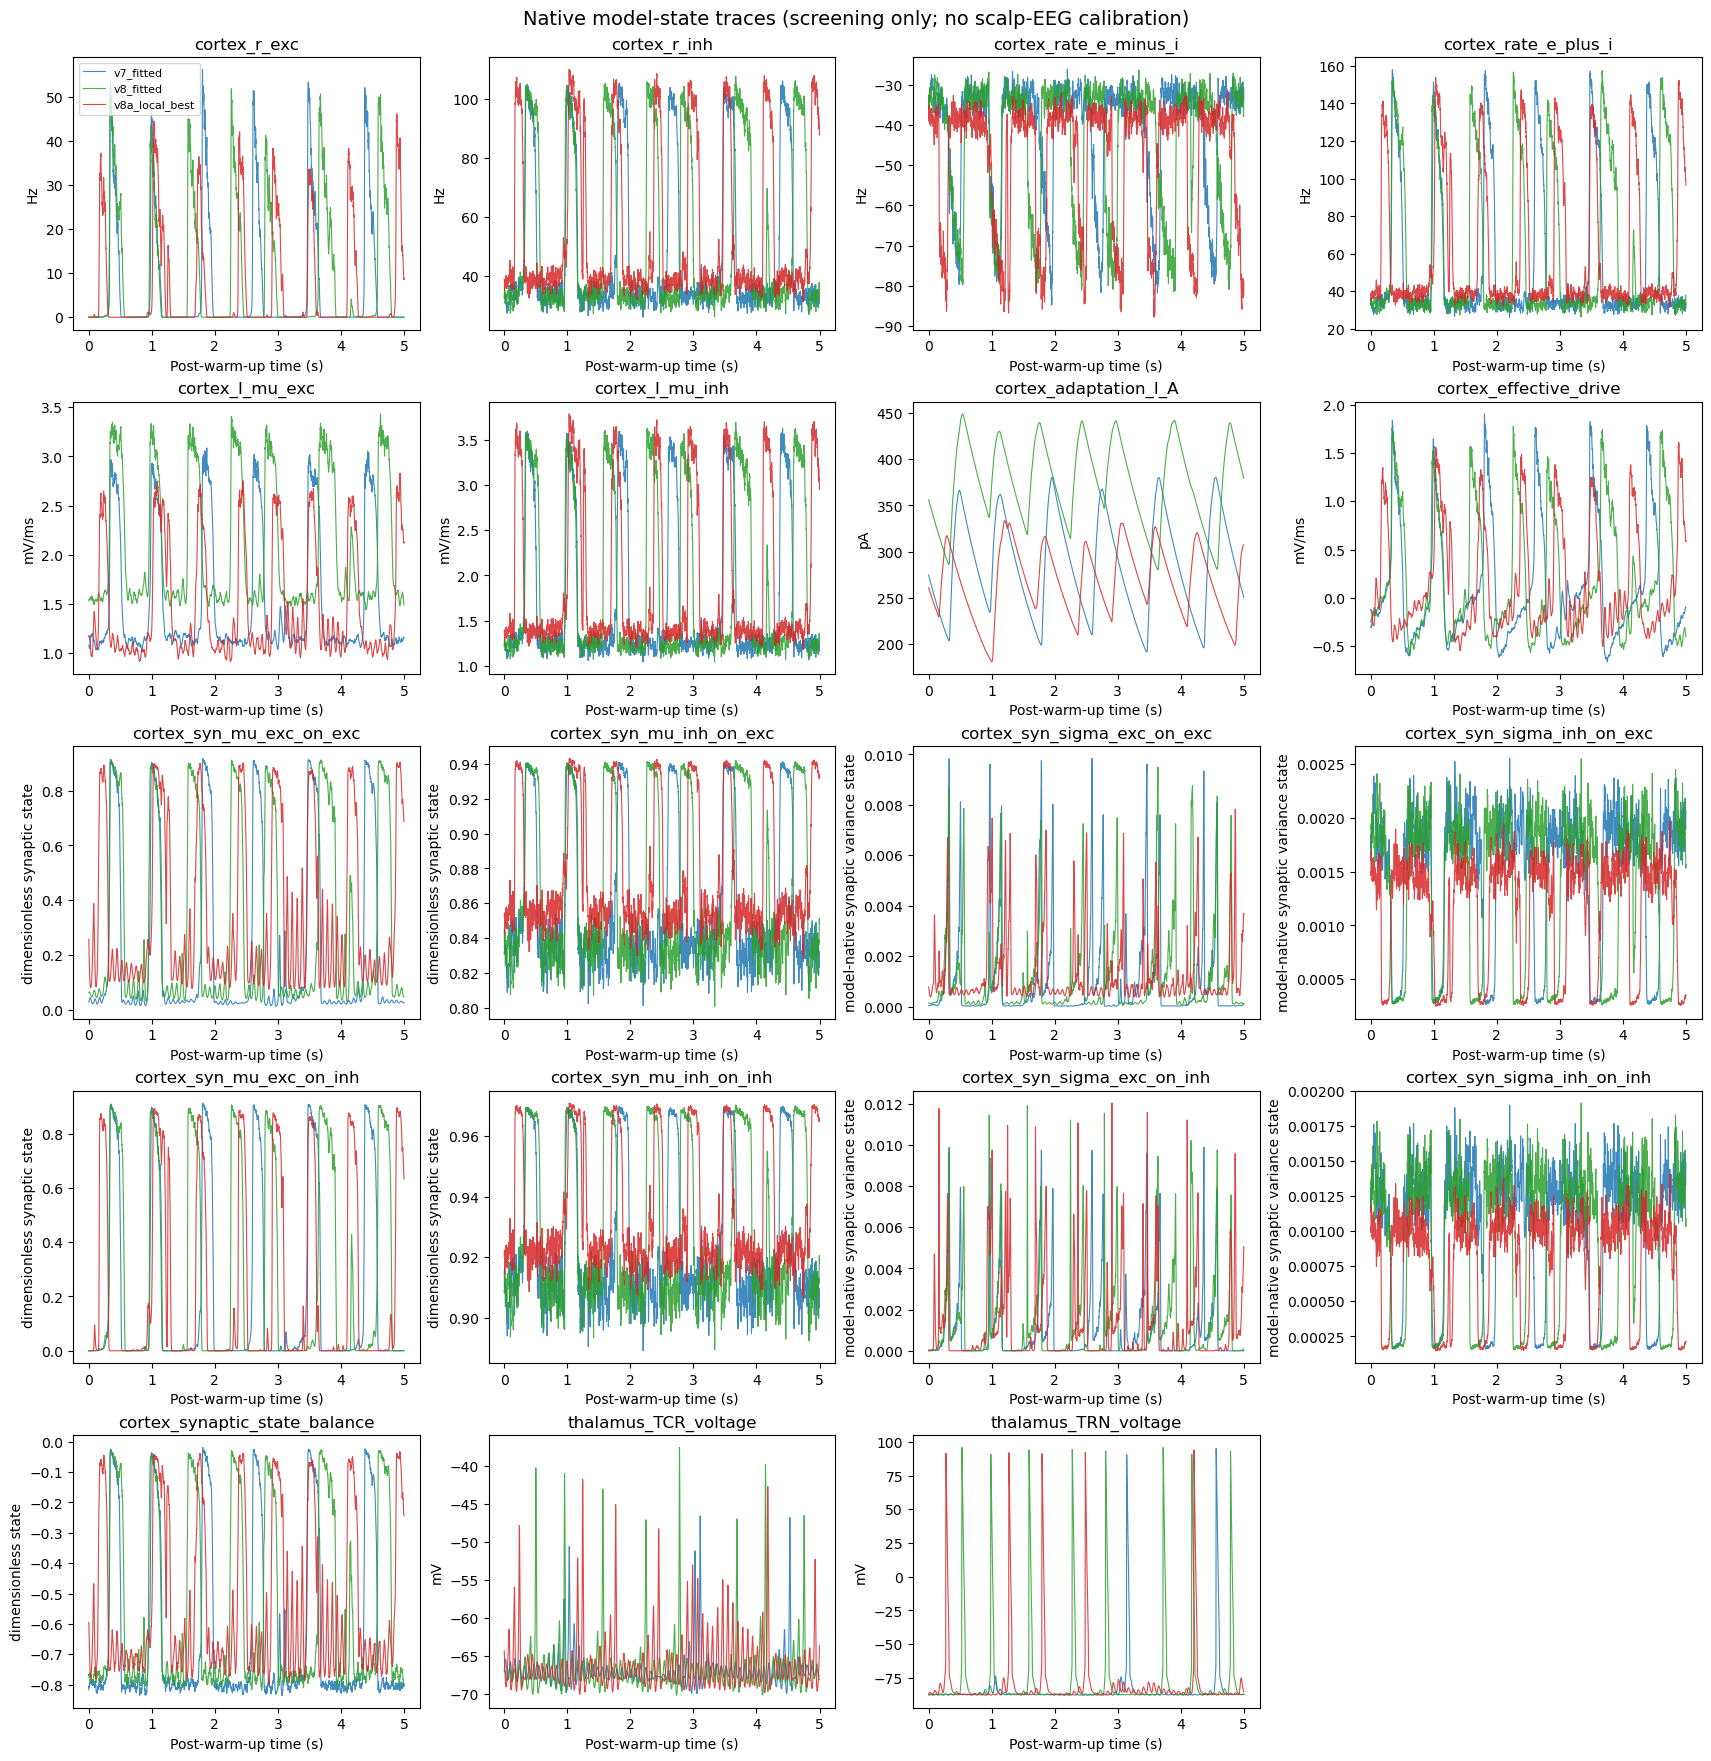

In [5]:
range_df = range_statistics(audits)
assert range_df["finite"].all()
display(range_df)

shown = list(audits[0].signals)
ncols = 4
nrows = int(np.ceil(len(shown) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.5 * nrows), constrained_layout=True)
colors = {"v7_fitted": "#1f77b4", "v8_fitted": "#2ca02c", "v8a_local_best": "#d62728"}
for ax, signal_name in zip(axes.flat, shown):
    for audit in audits:
        signal = audit.signals[signal_name]
        n = int(5 * audit.fs_hz)
        t = np.arange(n) / audit.fs_hz
        ax.plot(t, signal[:n], lw=0.8, alpha=0.85, color=colors[audit.parameter_set.identifier], label=audit.parameter_set.identifier)
    unit = audits[0].signal_metadata[signal_name]["unit"]
    ax.set(title=signal_name, xlabel="Post-warm-up time (s)", ylabel=unit)
for ax in axes.flat[len(shown):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Native model-state traces (screening only; no scalp-EEG calibration)", fontsize=14)
for ext in ["png", "svg"]:
    fig.savefig(FIG / f"native_model_state_traces.{ext}", dpi=180)
plt.show()

## 6. Standardized PSD and autocorrelation screening

For shape screening only:

- PSD is Hann-Welch, arithmetic-mean within the available epoch(s), then divided
  by its integral from 0.5 to 20 Hz.
- Autocorrelation is computed after z-scoring each 30-second epoch and never
  crosses an epoch boundary.
- `log_psd_spearman_vs_real` measures rank similarity of log unit-area spectra.
- `acf_rmse_vs_real` measures temporal-shape discrepancy.

Normalization removes amplitude and unit scale. It does **not** make the source
physics, sensor location, or reference equal. SO/sigma peaks can also move under
an unknown measurement operator, so even amplitude-insensitive summaries are
not automatically modality invariant.

,parameter_set,model_version,signal,standardization,log_psd_spearman_vs_real,acf_rmse_vs_real,relative_so_power_0p5_1p5,relative_sigma_power_11_15,so_peak_frequency_hz,sigma_peak_frequency_hz,finite,measurement_parity,interpretation
4,v7_fitted,v7,cortex_I_mu_exc,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.944742,0.283409,0.519043,0.007788,1.25,11.75,True,False,shape-level screening only
23,v8_fitted,v8,cortex_I_mu_exc,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.955915,0.158639,0.456484,0.010065,1.50,11.50,True,False,shape-level screening only
42,v8a_local_best,v8a_t13,cortex_I_mu_exc,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.956280,0.153055,0.356054,0.025729,1.50,12.50,True,False,shape-level screening only
5,v7_fitted,v7,cortex_I_mu_inh,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.926607,0.272290,0.490006,0.008471,1.25,13.00,True,False,shape-level screening only
24,v8_fitted,v8,cortex_I_mu_inh,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.945740,0.154746,0.439182,0.011913,1.50,11.50,True,False,shape-level screening only
43,v8a_local_best,v8a_t13,cortex_I_mu_inh,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.956426,0.152258,0.320068,0.021150,1.50,12.50,True,False,shape-level screening only
6,v7_fitted,v7,cortex_adaptation_I_A,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.978773,0.381171,0.758971,0.000390,1.25,11.75,True,False,shape-level screening only
25,v8_fitted,v8,cortex_adaptation_I_A,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.981646,0.164839,0.661581,0.000383,1.25,11.50,True,False,shape-level screening only
44,v8a_local_best,v8a_t13,cortex_adaptation_I_A,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.982522,0.134972,0.592676,0.000482,1.25,11.00,True,False,shape-level screening only
7,v7_fitted,v7,cortex_effective_drive,PSD unit-area 0.5-20 Hz; ACF z-score per epoch,0.940871,0.293041,0.539182,0.009020,1.25,11.75,True,False,shape-level screening only


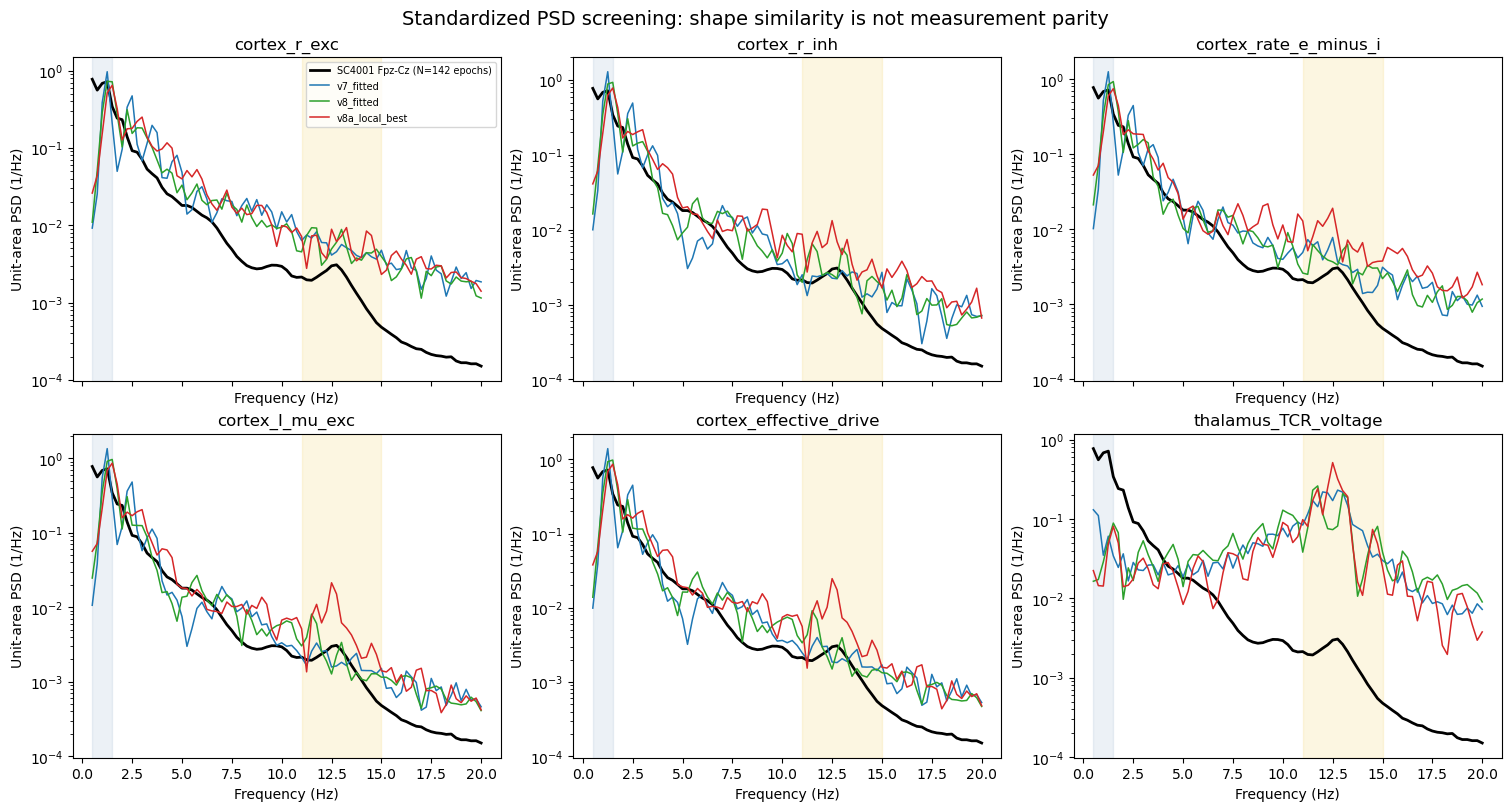

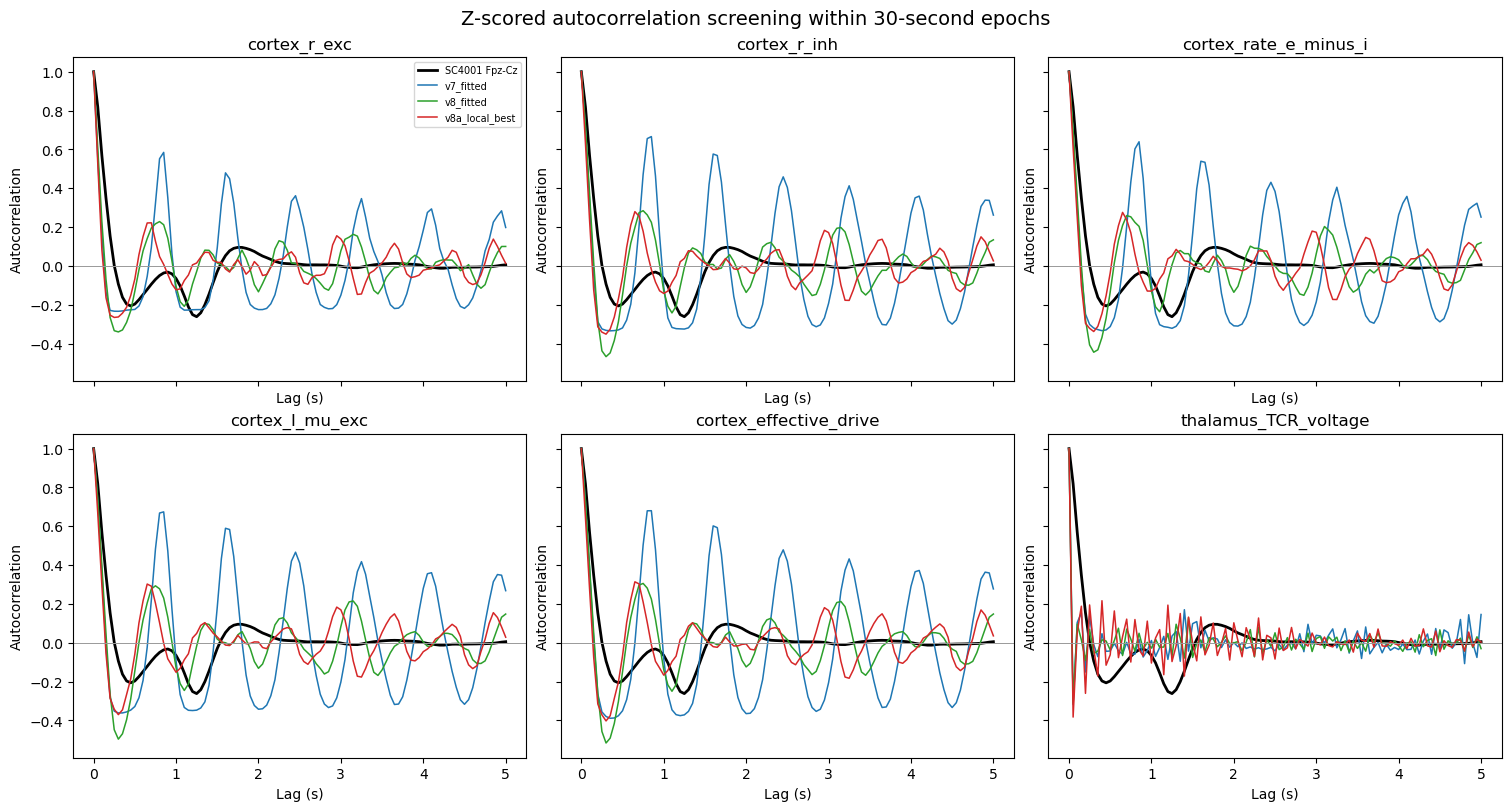

In [6]:
shape_df, curves = shape_metrics(audits, real)
assert shape_df["finite"].all()
assert not shape_df["measurement_parity"].any()
display(shape_df.sort_values(["signal", "parameter_set"]))

plot_signals = [
    "cortex_r_exc",
    "cortex_r_inh",
    "cortex_rate_e_minus_i",
    "cortex_I_mu_exc",
    "cortex_effective_drive",
    "thalamus_TCR_voltage",
]
real_mask = (real.frequencies_hz >= 0.5) & (real.frequencies_hz <= 20.0)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True, sharex=True)
for ax, signal_name in zip(axes.flat, plot_signals):
    ax.semilogy(real.frequencies_hz[real_mask], real.normalized_psd[real_mask], color="black", lw=2.0, label=f"SC4001 Fpz-Cz (N={len(real.segments_uv)} epochs)")
    for audit in audits:
        curve = curves[(audit.parameter_set.identifier, signal_name)]
        mask = (curve["frequencies_hz"] >= 0.5) & (curve["frequencies_hz"] <= 20.0)
        ax.semilogy(curve["frequencies_hz"][mask], curve["normalized_psd"][mask], lw=1.1, color=colors[audit.parameter_set.identifier], label=audit.parameter_set.identifier)
    ax.axvspan(0.5, 1.5, color="#4c78a8", alpha=0.10)
    ax.axvspan(11, 15, color="#f2cf5b", alpha=0.18)
    ax.set(title=signal_name, xlabel="Frequency (Hz)", ylabel="Unit-area PSD (1/Hz)")
axes.flat[0].legend(fontsize=7)
fig.suptitle("Standardized PSD screening: shape similarity is not measurement parity", fontsize=14)
for ext in ["png", "svg"]:
    fig.savefig(FIG / f"standardized_psd_screening.{ext}", dpi=180)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True, sharex=True, sharey=True)
for ax, signal_name in zip(axes.flat, plot_signals):
    ax.plot(real.acf_lags_s, real.mean_acf, color="black", lw=2.0, label="SC4001 Fpz-Cz")
    for audit in audits:
        curve = curves[(audit.parameter_set.identifier, signal_name)]
        ax.plot(curve["acf_lags_s"], curve["acf"], lw=1.1, color=colors[audit.parameter_set.identifier], label=audit.parameter_set.identifier)
    ax.axhline(0, color="0.6", lw=0.7)
    ax.set(title=signal_name, xlabel="Lag (s)", ylabel="Autocorrelation")
axes.flat[0].legend(fontsize=7)
fig.suptitle("Z-scored autocorrelation screening within 30-second epochs", fontsize=14)
for ext in ["png", "svg"]:
    fig.savefig(FIG / f"autocorrelation_screening.{ext}", dpi=180)
plt.show()

## 7. Existing EEG extractor: numerical success versus semantic failure

Each model signal is passed through the existing low-level EEG algorithms on
one complete post-warm-up 30-second window. This answers “does the code return a
number?”, not “is the number an EEG observation?”

- **PSD / relative bands / peak frequency:** insensitive to positive linear
  amplitude scale after normalization, but still sensitive to the measurement
  operator and source mixture.
- **SO events:** explicitly blocked because the detector requires a 75 $\mu V$
  half-wave. Applying 75 to Hz, pA, mV/ms, or internal mV is dimensionally false.
- **Spindles:** the RMS threshold is scale-adaptive, but zero events on a firing
  rate means only that this detector found no events in that signal. It does not
  prove absence of scalp spindles.
- **PAC:** MI may be scale-insensitive, but phase and amplitude are defined on a
  modality. Single-channel Fpz-Cz PAC is not the same object as cortical-rate
  phase with thalamic or rate amplitude.

,parameter_set,model_version,signal,unit,numerically_finite_input,global_qc_applicable,global_qc_reason,spectral_algorithm_runs,spectral_semantics_shared,so_algorithm_runs,...,pac_valid_epoch_count,pac_semantics_shared,failure_reason,spectral_failure_reason,so_valid_epoch_count,so_failure_reason,spindle_valid_epoch_count,spindle_failure_reason,pac_mi,pac_failure_reason
0,v7_fitted,v7,cortex_r_exc,Hz,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.088886,"filter/Hilbert calculation runs, but phase-amp..."
1,v7_fitted,v7,cortex_r_inh,Hz,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.033403,"filter/Hilbert calculation runs, but phase-amp..."
2,v7_fitted,v7,cortex_rate_e_minus_i,Hz,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.055008,"filter/Hilbert calculation runs, but phase-amp..."
3,v7_fitted,v7,cortex_rate_e_plus_i,Hz,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.058482,"filter/Hilbert calculation runs, but phase-amp..."
4,v7_fitted,v7,cortex_I_mu_exc,mV/ms,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.060454,"filter/Hilbert calculation runs, but phase-amp..."
5,v7_fitted,v7,cortex_I_mu_inh,mV/ms,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.036477,"filter/Hilbert calculation runs, but phase-amp..."
6,v7_fitted,v7,cortex_adaptation_I_A,pA,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.077589,"filter/Hilbert calculation runs, but phase-amp..."
7,v7_fitted,v7,cortex_effective_drive,mV/ms,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.059813,"filter/Hilbert calculation runs, but phase-amp..."
8,v7_fitted,v7,cortex_syn_mu_exc_on_exc,dimensionless synaptic state,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.027503,"filter/Hilbert calculation runs, but phase-amp..."
9,v7_fitted,v7,cortex_syn_mu_inh_on_exc,dimensionless synaptic state,True,False,200 uV peak-to-peak threshold has no cross-mod...,True,False,True,...,1,False,,numeric success; PSD unit metadata would be fa...,1,numeric result invalid for parity: detector ap...,1,"adaptive threshold runs, but zero/nonzero even...",0.015732,"filter/Hilbert calculation runs, but phase-amp..."


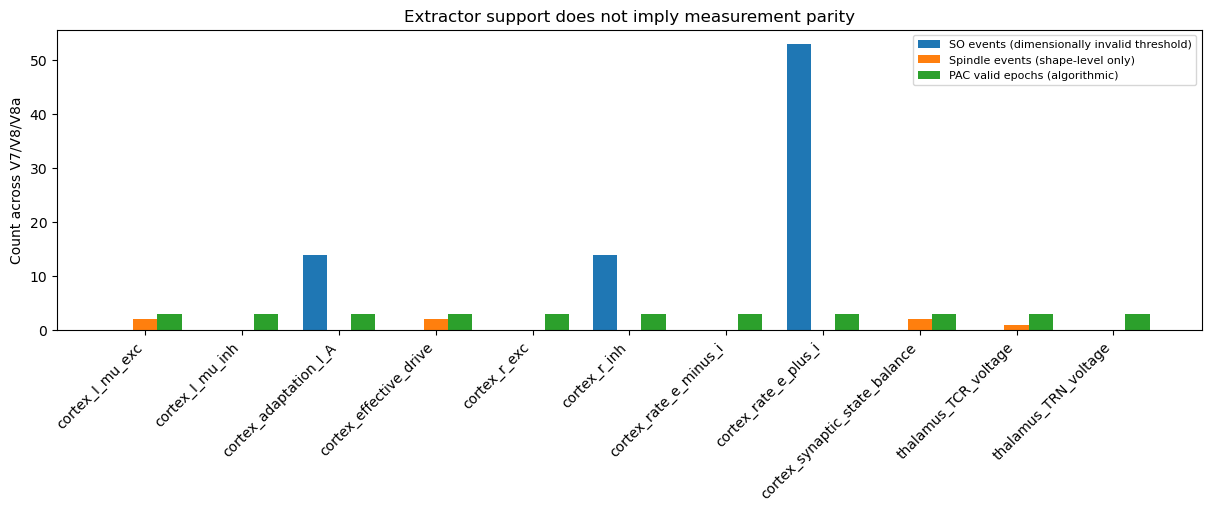

In [7]:
extractor_df = extractor_screening(audits)
assert not extractor_df["global_qc_applicable"].any()
assert not extractor_df["spectral_semantics_shared"].any()
assert not extractor_df["so_semantics_shared"].any()
assert not extractor_df["spindle_semantics_shared"].any()
assert not extractor_df["pac_semantics_shared"].any()
display(extractor_df)

support_signals = [
    "cortex_r_exc",
    "cortex_r_inh",
    "cortex_rate_e_minus_i",
    "cortex_rate_e_plus_i",
    "cortex_I_mu_exc",
    "cortex_I_mu_inh",
    "cortex_adaptation_I_A",
    "cortex_effective_drive",
    "cortex_synaptic_state_balance",
    "thalamus_TCR_voltage",
    "thalamus_TRN_voltage",
]
support_plot = (
    extractor_df[extractor_df["signal"].isin(support_signals)]
    .groupby("signal", as_index=False)
    .agg(
        so_events=("so_event_count", "sum"),
        spindle_events=("spindle_event_count", "sum"),
        pac_valid_epochs=("pac_valid_epoch_count", "sum"),
    )
)
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
x = np.arange(len(support_plot))
w = 0.25
ax.bar(x - w, support_plot["so_events"], width=w, label="SO events (dimensionally invalid threshold)")
ax.bar(x, support_plot["spindle_events"], width=w, label="Spindle events (shape-level only)")
ax.bar(x + w, support_plot["pac_valid_epochs"], width=w, label="PAC valid epochs (algorithmic)")
ax.set_xticks(x, support_plot["signal"], rotation=45, ha="right")
ax.set(ylabel="Count across V7/V8/V8a", title="Extractor support does not imply measurement parity")
ax.legend(fontsize=8)
for ext in ["png", "svg"]:
    fig.savefig(FIG / f"extractor_support_screening.{ext}", dpi=180)
plt.show()

## 8. Mapping options A-H

The decision table distinguishes availability from defensibility. Three points
are decisive:

1. A linear transform changes offset and amplitude, not the lead field, source
   mixture, bipolar reference, or noise process.
2. Fpz-Cz is a scalp voltage difference, not a direct cortical or thalamic state.
3. Inferring eight parameters through an unknown measurement operator creates
   parameter-to-observation non-identifiability: parameter changes and
   measurement changes can compensate for one another.

In [8]:
options_df = mapping_option_decisions()
display(options_df)

,option,available_in_current_code,physiological_meaning,units,can_use_eeg_extractor_unchanged,required_assumptions,identifiability_risk,leakage_risk,implementation_cost,scientific_defensibility,decision
0,A. Direct cortical firing rate,Yes; Figure 5/7 and adapter use r_mean_EXC,"population firing rate, not an electric field",Hz after kHz x 1000,No,rate spectrum stands in for bipolar scalp voltage,High,Medium if tuned on real EEG,Low,Shape screening only,Reject for real-EEG inference
1,B. Center/standardize/linearly scale firing rate,Mathematically available; z-scoring used in he...,dimensionless rate shape or arbitrarily scaled...,z or arbitrary uV,No,linear calibration substitutes for lead field/...,High,High if scale is fitted to SC4001 targets,Low,Does not repair channel semantics,Use only for explicit shape-level external val...
2,C. EXC/INH firing-rate combination,Both rates are recorded; weights are not defined,population-rate contrast/sum,Hz,No,unknown population and lead-field weights,Very high,High if weights selected using target,Low to medium,Uncalibrated screening contrast,Do not freeze as EEG proxy
3,D. Membrane-potential or synaptic-current proxy,Thalamic V and cortical current states exist; ...,internal membrane/current states,"mV, mV/ms, pA, dimensionless states",No,internal state projects directly to Fpz-Cz,High,Medium,Medium,"Closer biophysics, still no scalp measurement ...",Research candidate for a future forward model
4,E. Cortical mass/LFP-like observable,No validated implementation found,would approximate aggregate transmembrane/syna...,model dependent,No,"geometry, source orientation, conductivity and...",High,Medium,High,Potentially defensible after validation,Not currently available
5,F. Explicit EEG forward/measurement model,Generic neurolib leadfield utility exists; not...,source-to-sensor projection with channel/refer...,uV after calibrated gain,Only after validation,"define a dipole/source observable, map the two...",Medium to high,Must separate calibration and validation data,High,Required path; generic geometry code alone is ...,Recommended development route
6,G. Synthetic cortical-observable SBI only,Yes,parameters inferred from the same model observ...,native model units,"Use a model-observable extractor, not the EEG ...",claims restricted to synthetic recovery,Lower for synthetic task,Low,Medium,Defensible with explicit scope,Allowed interim route; not real-EEG inference
7,H. Pause SBI; real EEG as held-out external va...,Yes,qualitative/shape-level external comparison,modality-specific,No,no parameter inference from EEG,Low,Low,Low,Conservative and auditable,Use until a measurement model is validated


## 9. Formal route decision

### Recommendation: Route 2

**Implement and validate a measurement/forward model before real-EEG SNPE.**
No existing project variable satisfies a defensible Fpz-Cz measurement
contract. Therefore Route 1 is rejected.

Until Route 2 is completed, Route 3 is permitted only as an explicitly
synthetic task: infer parameters of the model from its own cortical observable.
Real EEG may remain a Route-4 held-out external shape check, but cannot be used
as if it shared the simulator observation space.

This audit does not authorize a simulation bank or pilot SNPE. The next gate
requires a documented source definition, forward/reference operator, unit
calibration independent of the target used for inference, simulation-side
noise model, and validation on held-out data or an external benchmark.

In [9]:
route_decision = {
    "recommended_route": "Route 2",
    "route_title": "Implement and validate a measurement/forward model before real-EEG inference",
    "route_1_shared_schema_go": False,
    "existing_validated_eeg_or_lfp_proxy_found": False,
    "existing_project_forward_model_found": False,
    "generic_neurolib_leadfield_utility_found": True,
    "interim_route_3_allowed": True,
    "interim_route_3_scope": "synthetic cortical-observable SBI only",
    "real_eeg_external_validation_allowed": True,
    "real_eeg_external_validation_scope": "held-out shape-level checks with modality caveats",
    "simulation_bank_authorized": False,
    "pilot_snpe_authorized": False,
    "required_next_gates": [
        "freeze a cortical source variable with explicit biophysical rationale",
        "define source geometry, projection/lead field, and Fpz-Cz bipolar reference",
        "define physical units, gain calibration, and sensor/noise model without target leakage",
        "validate SO, sigma/spindle, and PAC behavior on independent data",
        "rerun real-simulation parity with finite fixed-length vectors and matched semantics",
    ],
}
display(pd.Series(route_decision, name="decision").to_frame())

,decision
recommended_route,Route 2
route_title,Implement and validate a measurement/forward m...
route_1_shared_schema_go,False
existing_validated_eeg_or_lfp_proxy_found,False
existing_project_forward_model_found,False
generic_neurolib_leadfield_utility_found,True
interim_route_3_allowed,True
interim_route_3_scope,synthetic cortical-observable SBI only
real_eeg_external_validation_allowed,True
real_eeg_external_validation_scope,held-out shape-level checks with modality caveats


## 10. Artifact export, reload, and protected-file verification

Only aggregate tables, decisions, figures, hashes, and validation metadata are
saved. Full EEG segments and simulator traces remain in memory. Reload checks
ensure that the artifacts are readable and that all protected notebook hashes
remain unchanged.

In [10]:
artifacts = {
    "code_evidence.csv": code_evidence,
    "parameter_sets.csv": parameter_table,
    "simulation_run_summary.csv": run_summary,
    "simulator_state_variable_catalog.csv": catalog,
    "proxy_range_statistics.csv": range_df,
    "proxy_shape_metrics.csv": shape_df,
    "extractor_screening.csv": extractor_df,
    "mapping_option_decisions.csv": options_df,
}
for filename, frame in artifacts.items():
    frame.to_csv(OUT / filename, index=False)

(OUT / "environment_report.json").write_text(
    json.dumps(environment_report, indent=2, ensure_ascii=False), encoding="utf-8"
)
(OUT / "route_decision.json").write_text(
    json.dumps(route_decision, indent=2, ensure_ascii=False), encoding="utf-8"
)

protected_hashes_end = {
    rel: sha256(ROOT / rel) for rel in protected_hashes_start
}
assert protected_hashes_end == protected_hashes_start

reload_checks = {}
for filename, frame in artifacts.items():
    loaded = pd.read_csv(OUT / filename)
    reload_checks[filename] = {
        "readable": True,
        "rows": int(len(loaded)),
        "columns": int(len(loaded.columns)),
        "expected_rows": int(len(frame)),
        "row_count_match": bool(len(loaded) == len(frame)),
    }
for filename in ["environment_report.json", "route_decision.json"]:
    loaded = json.loads((OUT / filename).read_text(encoding="utf-8"))
    reload_checks[filename] = {"readable": True, "top_level_keys": sorted(loaded)}

git_status_end = subprocess.run(
    ["git", "status", "--short"], cwd=ROOT, text=True, capture_output=True, check=True
).stdout.splitlines()
git_diff_stat_end = subprocess.run(
    ["git", "diff", "--stat"], cwd=ROOT, text=True, capture_output=True, check=True
).stdout.splitlines()

validation_report = {
    "nbformat_validation": "performed after execution by validation script",
    "parameter_sets_run": [a.parameter_set.identifier for a in audits],
    "simulation_count": len(audits),
    "all_simulator_signals_finite": bool(range_df["finite"].all()),
    "real_epoch_accounting": {
        "n3": int(len(real.n3_epoch_indices)),
        "retained": int(len(real.retained_epoch_indices)),
        "rejected": int(len(real.rejected_epoch_indices)),
        "identity_pass": bool(len(real.retained_epoch_indices) + len(real.rejected_epoch_indices) == len(real.n3_epoch_indices)),
    },
    "existing_measurement_model_found": False,
    "measurement_parity_pass": False,
    "recommended_route": route_decision["recommended_route"],
    "protected_notebook_hashes_unchanged": True,
    "artifact_reload_checks": reload_checks,
    "raw_eeg_arrays_saved": False,
    "raw_simulator_arrays_saved": False,
    "simulation_bank_created": False,
    "snpe_started": False,
    "git_status_short_end": git_status_end,
    "git_diff_stat_end": git_diff_stat_end,
}
(OUT / "validation_report.json").write_text(
    json.dumps(validation_report, indent=2, ensure_ascii=False), encoding="utf-8"
)
reloaded_validation = json.loads((OUT / "validation_report.json").read_text(encoding="utf-8"))
assert reloaded_validation["artifact_reload_checks"] == reload_checks

display(pd.DataFrame(reload_checks).T)
print("Protected hashes unchanged:", protected_hashes_end == protected_hashes_start)
print("git status --short (end):")
print("\n".join(git_status_end))
print("\ngit diff --stat (end):")
print("\n".join(git_diff_stat_end))

,readable,rows,columns,expected_rows,row_count_match,top_level_keys
code_evidence.csv,True,13,4,13,True,NaN
parameter_sets.csv,True,3,11,3,True,NaN
simulation_run_summary.csv,True,3,11,3,True,NaN
simulator_state_variable_catalog.csv,True,19,8,19,True,NaN
proxy_range_statistics.csv,True,57,15,57,True,NaN
proxy_shape_metrics.csv,True,57,13,57,True,NaN
extractor_screening.csv,True,57,26,57,True,NaN
mapping_option_decisions.csv,True,8,11,8,True,NaN
environment_report.json,True,NaN,NaN,NaN,NaN,"[conda_default_env, created_utc, git_diff_stat..."
route_decision.json,True,NaN,NaN,NaN,NaN,"[existing_project_forward_model_found, existin..."


Protected hashes unchanged: True
git status --short (end):
 D S4_sbi/compute_xobs_from_eeg.py
 D S4_sbi/compute_xobs_from_eeg_v1_buggy.py
 D S4_sbi/compute_xobs_from_eeg_v2.py
 M S4_sbi/compute_xobs_from_eeg_v4.py
 M S4_sbi/notebooks/01_Pyloric_Inspired_Observation_annotated.ipynb
 D S4_sbi/plot_scan_diagnostics.py
 D S4_sbi/run_sbc_standalone.py
 D S4_sbi/scan_xobs_params.py
 D S4_sbi/x_obs.npz
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.docx
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.md
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.tex
 M docs/Claude_Writing/build_manuscript_docx.py
 M docs/implementation_plan_v8_progress_1.md
 M models/s4_personalize_fig7_v2.py
 M valid_scripts/validate_so_waveform_heldout.py
 M valid_scripts/validate_spindle_density_heldout.py
?? S4_sbi/legacy/
?? S4_sbi/notebooks/02_Observation_Schema_Comparison.ipynb
?? S4_sbi/notebooks/03_Observation_Schema_Freeze.ipynb
?? S4_sbi/notebooks/04_Real_Simulation_Extractor_Parity.ipynb
?? S4_sbi/noteboo

## 11. Conclusions and researcher decisions

### What the evidence supports

- Figure 5/7 used cortical excitatory firing-rate PSD against an Fpz-Cz EEG PSD.
- Neurolib contains useful internal states, including ALN current/adaptation
  variables and TCR/TRN membrane voltages.
- Normalized PSD, SO peak frequency, relative band power, and autocorrelation
  can be screened across modalities as shape descriptors.

### What the evidence does not support

- No inspected variable is a validated scalp-EEG or cortical-LFP output.
- A 75 $\mu V$ SO threshold cannot migrate to native model units.
- Zero model-rate spindle events do not mean zero real scalp spindles.
- PAC phase, preferred phase, and amplitude coupling are not measurement
  invariant.
- Single-channel Fpz-Cz cannot directly reveal thalamic voltage, spindle onset,
  propagation latency, or directional thalamocortical coupling.

### Manual decisions required next

1. Choose whether the scientific target is real-EEG inference (Route 2) or
   synthetic cortical-observable recovery (Route 3).
2. If Route 2, select and justify a cortical source observable: reconstructed
   ALN mean voltage, transmembrane/synaptic-current proxy, or another validated
   neural-mass source.
3. Specify the Fpz-Cz measurement contract: source geometry, lead field,
   bipolar reference, gain/units, and sensor/noise model.
4. Reserve independent data for calibrating and validating the measurement
   operator so the observed record does not leak into feature construction.
5. Decide which EEG summaries remain held out after the measurement model is
   validated; SO amplitude, spindle detection, and PAC require separate gates.

**Current gate:** do not generate a real-EEG simulation bank and do not run
pilot SNPE. Route 2 must be addressed first; Route 3 may proceed later only with
an explicitly synthetic claim.